In [1]:
import pandas as pd
import starsim as ss
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats

# 2.0 Explore People
In `1_run_geopops.ipynb`, we made a 2019 population of Spartanburg County, SC. `ForStarsim.People()` outputs a file called `people_all.csv` that lists agents and their attributes for people living in Spartanburg and those that live outside Spartanburg and commute in for work. In this notebook, we'll:
* 2.1 See how `people_all.csv` translates to the Starsim People object
* 2.2 Add agent attributes to the People object
* 2.3 Compare the synthesized population to real Census data for households by size and for sex by age group
* 2.4 Assess the accuracy of the synthesized population using the Freeman-Tukey statistic

## 2.1 Starsim People object
In `people_all.csv`, each agent is uniquely identified by three variables: p_id, hh_id, and cbg_id (later we'll give each agent a single unique identifier for Starsim). The other columns are as follows:

| Variable name | Definition | 
| -------- | -------- | 
| uid | Unique ID for each agent used by Starsim |
| p_id | GeoPops person ID which uniquely identifies each agent when combined with hh_id and cbg_id |
| hh_id | GeoPops household ID which uniquely identifies households when combined with cbg_id. List of households in `pop_export/hh.csv` |
| cbg_id | GeoPops cbg id (reduces memory storage). `pop_export/cbg_idxs.csv` maps cbg_id to 12-digit FIPS code |
| sample_index| Refers to the PUMS sample household that this agent belongs to. PUMS households listed in `processed/census_samples.csv` |
| age | Agent age by 1-year increments |
| female| 1=female; 0=male |
| working| 1=working; 0=not working |
| commuter| 1=home CBG is different from workpace CBG; 0=does not commute to work |
| commuter_income_category| 1<=40k; 2>40k  (can be adjusted with `geopops.Config()`) |
| commuter_workplace_category| 1-15, corresponds to NAICS codes in table below |
| race_black_alone| 1=race Black alone; 0=not race Black alone |
| white_non_hispanic| 1=White not Hispanic; 0=not White not Hispanic |
| hispanic| 1=Hispanic; 0=not Hispanic |
| race_ethnicity | 0=Black alone; 1=Hispanic; 2=White non-Hispanic
| sch_grade| p=pre-k; k=kintergarden, grades 1-12, c=college, g=graduate school |

Each agent living inside the geo area (e.g., Spartanburg) has attribute data for all variables, except agents who live in group quarters (GQ) who only have age data. Agents who live outside the geo area and commute in for work do not have any attribute data but are represented in the workplace network. Commuters are agents whose home census block group (CBG) is different from their workplace CBG. For commuters, we also have NAICS workplace categories from the ACS and CBP data.

| NAICS code | Category | 
| -------- | -------- | 
| 1 | Agriculture forestry fishing and hunting and mining |
| 2 | Construction |
| 3 | Manufacturing |
| 4 | Wholesale trade |
| 5 | Retail trade |
| 6 | Transportation and warehousing and utilities |
| 7 | Information |
| 8 | Finance and insurance and real estate and rental and leasing |
| 9 | Professional scientific and management and administrative and waste management services |
| 10| Educational services and health care and social assistance:Educational services |
| 11| Educational services and health care and social assistance:Health care and social assistance |
| 12| Arts entertainment and recreation and accommodation and food services:Arts entertainment and recreation |
| 13| Arts entertainment and recreation and accommodation and food services:Accommodation and food services |
| 14| Other services except public administration |
| 15| Public Administration, Armed Forces |


In [2]:
# Read and view people_all.csv
people_all = pd.read_csv('data/pop_export/people_all.csv')
people_all

/var/folders/9n/1361ppx53h5cjy3q80rwhj540000gn/T/ipykernel_49027/3377809747.py:2: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  people_all = pd.read_csv('data/pop_export/people_all.csv')


,uid,p_id,hh_id,cbg_id,sample_index,state,county,tract,cbg_geocode,household,...,race_black_alone,white_non_hispanic,hispanic,race_ethnicity,working,commuter,commuter_income_category,commuter_workplace_category,sch_grade,sch_code
0,0,2,515,121,40736.0,45.0,45083.0,4.508302e+10,4.508302e+11,69678.0,...,0.0,1.0,0.0,2.0,1.0,1.0,1.0,3.0,NaN,0.000000e+00
1,1,1,173,53,193547.0,45.0,45083.0,4.508302e+10,4.508302e+11,31459.0,...,1.0,0.0,0.0,NaN,1.0,1.0,2.0,4.0,NaN,0.000000e+00
2,2,5,12,112,133937.0,45.0,45083.0,4.508302e+10,4.508302e+11,64167.0,...,0.0,1.0,0.0,2.0,0.0,0.0,NaN,NaN,10,4.503630e+11
3,3,1,71,173,112396.0,45.0,45083.0,4.508302e+10,4.508302e+11,101202.0,...,0.0,1.0,0.0,2.0,1.0,1.0,2.0,15.0,NaN,0.000000e+00
4,4,1,734,120,51273.0,45.0,45083.0,4.508302e+10,4.508302e+11,69147.0,...,0.0,1.0,0.0,2.0,1.0,1.0,1.0,10.0,NaN,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357230,357230,55290,0,0,NaN,0.0,0.0,0.000000e+00,0.000000e+00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
357231,357231,55291,0,0,NaN,0.0,0.0,0.000000e+00,0.000000e+00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
357232,357232,55292,0,0,NaN,0.0,0.0,0.000000e+00,0.000000e+00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
357233,357233,55293,0,0,NaN,0.0,0.0,0.000000e+00,0.000000e+00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00


`ForStarsim.People()` makes a Starsim People object from `people_all` and turns some attributes into what Starsim calls 'states'. The people object is stored as `pop_export/starsim/ppl.pkl`. The people object is what Starsim uses to track agents throughout a simulation. This allows you to target agents with certain states in interventions and track outcomes by subgroups.

| State | Definition | 
| -------- | -------- | 
| uid | Unique agent identifier. Corresponds to uid in people_all and nodes in networks (will explore networks later)|
| slot | Index array used internally for random number management |
| alive | True=alive or False=deceased |
| age | Agent age in 1-year increments |
| female | 0.0=male; 1.0=female| 
| ti_dead | Time step when agent dies |
| ti_removed | Time step when agent removed from simulation (e.g., emigration) | 
| scale | How many agents this agent represents |
| agegroup | Agent age in 10-year age bins |
| race_ethnicity | 0.0=Black alone; 1.0=Hispanic; 2.0 White non-Hispanic | 
| cbg_geocode | 12-digit CBG FIPS code |

In [3]:
# View Starsim People object and states
ppl = ss.load('data/pop_export/starsim/ppl.pkl') # load the people object
sim = ss.Sim(people=ppl).init() # initialize the simulation (only way you can access the people object as a dataframe)
ppl_df = sim.people.to_df()
ppl_df

Initializing sim with 357235 agents


,uid,slot,alive,age,female,ti_dead,ti_removed,scale,agegroup,race_ethnicity,state,county,tract,cbg_geocode,household,commuter,commuter_income_category,commuter_workplace_category,sch_code
0,0,0,True,47.0,0.0,NaN,NaN,1.0,4.0,2.0,45,45083,45083023700,450830237001,69678,1.0,1.0,3.0,0
1,1,1,True,49.0,0.0,NaN,NaN,1.0,4.0,NaN,45,45083,45083021001,450830210013,31459,1.0,2.0,4.0,0
2,2,2,True,15.0,1.0,NaN,NaN,1.0,1.0,2.0,45,45083,45083023500,450830235002,64167,0.0,NaN,NaN,450363001038
3,3,3,True,49.0,0.0,NaN,NaN,1.0,4.0,2.0,45,45083,45083023202,450830232021,101202,1.0,2.0,15.0,0
4,4,4,True,63.0,0.0,NaN,NaN,1.0,6.0,2.0,45,45083,45083023301,450830233011,69147,1.0,1.0,10.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357230,357230,357230,True,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,0
357231,357231,357231,True,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,0
357232,357232,357232,True,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,0
357233,357233,357233,True,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,0


All the NaNs at the end of the people object dataframe are dummy agents who live outside the geo area and commute in for work. Dummy agents do not have attributes but are represented in the work network. Group quarters agents only have the age attribute because the Decennial Census does not have group quarters disaggregated by gender or other variables.

## 2.2 Add agent attributes to People object
To reduce memory usage during a simulation, GeoPops does not include all attributes from people_all in the Starsim People object by default. But you can add any attribute from your GeoPops population as a state after the fact if it's relevant to your research question. You could also use the files in pop_export that list agents by school, workplace, and GQ facility to turn these into states. Then you could target schools, workplaces, or GQs in interventions. 

For the example of measles in Spartanburg, we want an attribute for vaccination status. The [SC DPH website](https://dph.sc.gov/diseases-conditions/infectious-diseases/measles-rubeola#:~:text=Based%20on%20the%202021%20CDC,one%20dose%20of%20MMR%20vaccine.) states that 92.1% of kindergarten students had two doses of the MMR vaccine in 2023-2024, down from 95% for the 2019-2020 school year. Even though our population is technical from 2019, we'll use the more recent vaccination coverage rate and assign this to all chidren under 18. You could apply different rates to different age groups.

So, the next cell identifies school children (agents under 18) who live in Spartanburg and assigns 92% to have vax_status=1 and 10% to have vax_status=0.

In [4]:
mask = (people_all['age'] >=1 ) & (~people_all['age'].isnull()) # find agents with age attribute who are over 1 year old
people_all.loc[mask, 'vax_status'] = np.random.binomial(1, 0.92, size=mask.sum()) # assign 90% to vax_status=1
vax_status = ss.FloatArr('vax_status', default=ss.BaseArr(people_all['vax_status'].values)) # Turn this array into a Starsim FloatArr
# Add the vax_status state to the existing people object 
ppl.states.append(vax_status) 
setattr(ppl, vax_status.name, vax_status)
vax_status.link_people(ppl)

# Overwrite the existing people object with the new one
ss.save(f'data/pop_export/starsim/ppl_vax.pkl', ppl)

# View the new people object
ppl = ss.load(f'data/pop_export/starsim/ppl_vax.pkl')
sim = ss.Sim(people=ppl).init()
ppl_df = sim.people.to_df()
ppl_df

Initializing sim with 357235 agents


,uid,slot,alive,age,female,ti_dead,ti_removed,scale,agegroup,race_ethnicity,state,county,tract,cbg_geocode,household,commuter,commuter_income_category,commuter_workplace_category,sch_code,vax_status
0,0,0,True,47.0,0.0,NaN,NaN,1.0,4.0,2.0,45,45083,45083023700,450830237001,69678,1.0,1.0,3.0,0,1.0
1,1,1,True,49.0,0.0,NaN,NaN,1.0,4.0,NaN,45,45083,45083021001,450830210013,31459,1.0,2.0,4.0,0,1.0
2,2,2,True,15.0,1.0,NaN,NaN,1.0,1.0,2.0,45,45083,45083023500,450830235002,64167,0.0,NaN,NaN,450363001038,1.0
3,3,3,True,49.0,0.0,NaN,NaN,1.0,4.0,2.0,45,45083,45083023202,450830232021,101202,1.0,2.0,15.0,0,1.0
4,4,4,True,63.0,0.0,NaN,NaN,1.0,6.0,2.0,45,45083,45083023301,450830233011,69147,1.0,1.0,10.0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357230,357230,357230,True,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,0,NaN
357231,357231,357231,True,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,0,NaN
357232,357232,357232,True,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,0,NaN
357233,357233,357233,True,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0,0,0,0,0,NaN,NaN,NaN,0,NaN


Now, we have a new people object where agents also have attributes of vax_status, household, and tract.

## 2.3.1 Households by size comparison
Let's see how the synthesized population compares to actual Census data. In `1_run_geopops.ipynb`, `geopops.Download_data()` downloads ACS tables into the folder census/SC. Table B11016 has household size data and is stored in the file `ACSDT5Y[YEAR].B11016-Data.csv`. The following cells format GeoPops and ACS data so we can plot a comparison of households by household size.

In [ ]:
# Process ACS by household size 
B11016 = pd.read_csv('data/census/SC/ACSDT5Y2019.B11016-Data.csv', header=1)
# Filter for Spartanburg County
B11016['county'] = B11016['Geography'].astype(str).str[9:14].astype(int)
B11016 = B11016[B11016['county'] == 45083]
B11016.head()

,Geography,NAME,Estimate!!Total:,Estimate!!Total:!!Family households:,Estimate!!Total:!!Family households:!!2-person household,Estimate!!Total:!!Family households:!!3-person household,Estimate!!Total:!!Family households:!!4-person household,Estimate!!Total:!!Family households:!!5-person household,Estimate!!Total:!!Family households:!!6-person household,Estimate!!Total:!!Family households:!!7-or-more person household,Estimate!!Total:!!Nonfamily households:,Estimate!!Total:!!Nonfamily households:!!1-person household,Estimate!!Total:!!Nonfamily households:!!2-person household,Estimate!!Total:!!Nonfamily households:!!3-person household,Estimate!!Total:!!Nonfamily households:!!4-person household,Estimate!!Total:!!Nonfamily households:!!5-person household,Estimate!!Total:!!Nonfamily households:!!6-person household,Estimate!!Total:!!Nonfamily households:!!7-or-more person household,county
226,1500000US450830213023,"Block Group 3, Census Tract 213.02, Spartanbur...",510,450,227,98,82,37,6,0,60,60,0,0,0,0,0,0,45083
227,1500000US450830213022,"Block Group 2, Census Tract 213.02, Spartanbur...",132,90,40,6,34,0,10,0,42,36,6,0,0,0,0,0,45083
228,1500000US450830217003,"Block Group 3, Census Tract 217, Spartanburg C...",707,507,160,218,53,19,57,0,200,191,9,0,0,0,0,0,45083
229,1500000US450830212003,"Block Group 3, Census Tract 212, Spartanburg C...",603,243,134,18,62,22,7,0,360,259,80,21,0,0,0,0,45083
230,1500000US450830212002,"Block Group 2, Census Tract 212, Spartanburg C...",491,316,154,80,49,33,0,0,175,168,7,0,0,0,0,0,45083


In [8]:
# Make columns for counts by household size
acs_hh = B11016.copy()
acs_hh['1'] = acs_hh['Estimate!!Total:!!Nonfamily households:!!1-person household']
acs_hh['2'] = acs_hh['Estimate!!Total:!!Family households:!!2-person household'] + acs_hh['Estimate!!Total:!!Nonfamily households:!!2-person household']
acs_hh['3'] = acs_hh['Estimate!!Total:!!Family households:!!3-person household'] + acs_hh['Estimate!!Total:!!Nonfamily households:!!3-person household']
acs_hh['4'] = acs_hh['Estimate!!Total:!!Family households:!!4-person household'] + acs_hh['Estimate!!Total:!!Nonfamily households:!!4-person household']
acs_hh['5'] = acs_hh['Estimate!!Total:!!Family households:!!5-person household'] + acs_hh['Estimate!!Total:!!Nonfamily households:!!5-person household']
acs_hh['6'] = acs_hh['Estimate!!Total:!!Family households:!!6-person household'] + acs_hh['Estimate!!Total:!!Nonfamily households:!!6-person household']
acs_hh['7+'] = acs_hh['Estimate!!Total:!!Family households:!!7-or-more person household'] + acs_hh['Estimate!!Total:!!Nonfamily households:!!7-or-more person household']
acs_hh = acs_hh[['1','2','3','4','5','6','7+']]
acs_hh = acs_hh.fillna(0)
acs_hh = acs_hh.sum().reset_index().rename(columns={'index':'hh_size',0:'acs'})
print('ACS number of households by size')
acs_hh


ACS number of households by size


,hh_size,acs
0,1,31957
1,2,40893
2,3,19576
3,4,13889
4,5,6512
5,6,2599
6,7+,1219


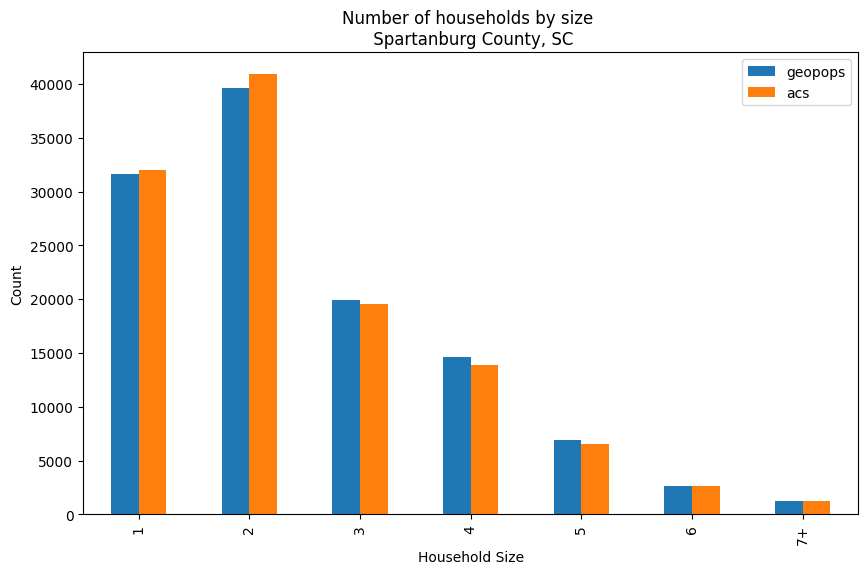

In [9]:
# Process GeoPops households by size
geopops_hh = pd.read_csv('data/pop_export/hh.csv')
cbg_idxs = pd.read_csv('data/pop_export/cbg_idxs.csv')
geopops_hh = geopops_hh.merge(cbg_idxs, on='cbg_id', how='left')
geopops_hh['count'] = 1
geopops_hh.loc[geopops_hh['n_people'] >=7, 'n_people'] = 7
geopops_hh = geopops_hh.groupby(['n_people'])['count'].sum().reset_index()
geopops_hh.rename(columns={'n_people':'hh_size', 'count':'geopops'}, inplace=True)
geopops_hh['hh_size'] = geopops_hh['hh_size'].astype(str)
geopops_hh.loc[geopops_hh['hh_size'] =='7', 'hh_size'] = '7+'

# Merge GeoPops and ACS data
compare_hh_size = geopops_hh.merge(acs_hh, on='hh_size', how='left').set_index('hh_size')

# Make bar plot of comparison
compare_hh_size.plot(kind='bar', figsize=(10, 6))
plt.title('Number of households by size \n Spartanburg County, SC')
plt.xlabel('Household Size')
plt.ylabel('Count')
plt.show()

## 2.3.2 Sex by age group comparison
Now we'll do the same for sex by age group. ACS table B01001 has sex by age data and is stored in the file `ACSDT5YYEAR.B01001-Data.csv`.

In [10]:
# Process ACS by sex and age group
# Read in B01001
B01001 = pd.read_csv('data/census/SC/ACSDT5Y2019.B01001-Data.csv', header=1)

# Filter by county to get Spartanburg residents only
B01001['county'] = B01001['Geography'].astype(str).str[9:14].astype(int)
B01001 = B01001[B01001['county'] == 45083]
B01001.head()

,Geography,NAME,Estimate!!Total:,Estimate!!Total:!!Male:,Estimate!!Total:!!Male:!!Under 5 years,Estimate!!Total:!!Male:!!5 to 9 years,Estimate!!Total:!!Male:!!10 to 14 years,Estimate!!Total:!!Male:!!15 to 17 years,Estimate!!Total:!!Male:!!18 and 19 years,Estimate!!Total:!!Male:!!20 years,...,Estimate!!Total:!!Female:!!55 to 59 years,Estimate!!Total:!!Female:!!60 and 61 years,Estimate!!Total:!!Female:!!62 to 64 years,Estimate!!Total:!!Female:!!65 and 66 years,Estimate!!Total:!!Female:!!67 to 69 years,Estimate!!Total:!!Female:!!70 to 74 years,Estimate!!Total:!!Female:!!75 to 79 years,Estimate!!Total:!!Female:!!80 to 84 years,Estimate!!Total:!!Female:!!85 years and over,county
3,1500000US450830233023,"Block Group 3, Census Tract 233.02, Spartanbur...",932,441,75,0,0,0,0,0,...,11,12,10,0,9,9,10,19,11,45083
47,1500000US450830220042,"Block Group 2, Census Tract 220.04, Spartanbur...",1167,569,115,70,0,13,34,11,...,14,0,22,43,0,44,13,0,26,45083
64,1500000US450830232011,"Block Group 1, Census Tract 232.01, Spartanbur...",2244,1024,43,45,11,29,25,22,...,122,21,34,29,51,57,39,31,30,45083
78,1500000US450830235001,"Block Group 1, Census Tract 235, Spartanburg C...",768,302,0,0,0,0,15,0,...,42,0,21,30,70,28,32,0,0,45083
102,1500000US450830224032,"Block Group 2, Census Tract 224.03, Spartanbur...",1956,956,0,111,83,31,41,9,...,69,30,55,0,12,27,0,15,18,45083


In [11]:
# Create columns for counts by sex by age group
acs_sex_age = B01001.copy()

# male by age group
acs_sex_age['male_0_9']   = acs_sex_age['Estimate!!Total:!!Male:!!Under 5 years'] + acs_sex_age['Estimate!!Total:!!Male:!!5 to 9 years'] 
acs_sex_age['male_10_19'] = acs_sex_age['Estimate!!Total:!!Male:!!10 to 14 years'] + acs_sex_age['Estimate!!Total:!!Male:!!15 to 17 years'] + acs_sex_age['Estimate!!Total:!!Male:!!18 and 19 years'] 
acs_sex_age['male_20_29'] = acs_sex_age['Estimate!!Total:!!Male:!!20 years'] + acs_sex_age['Estimate!!Total:!!Male:!!21 years'] + acs_sex_age['Estimate!!Total:!!Male:!!22 to 24 years'] + acs_sex_age['Estimate!!Total:!!Male:!!25 to 29 years'] 
acs_sex_age['male_30_39'] = acs_sex_age['Estimate!!Total:!!Male:!!30 to 34 years'] + acs_sex_age['Estimate!!Total:!!Male:!!35 to 39 years']
acs_sex_age['male_40_49'] = acs_sex_age['Estimate!!Total:!!Male:!!40 to 44 years'] + acs_sex_age['Estimate!!Total:!!Male:!!45 to 49 years'] 
acs_sex_age['male_50_59'] = acs_sex_age['Estimate!!Total:!!Male:!!50 to 54 years'] + acs_sex_age['Estimate!!Total:!!Male:!!55 to 59 years'] 
acs_sex_age['male_60_69'] = acs_sex_age['Estimate!!Total:!!Male:!!60 and 61 years'] + acs_sex_age['Estimate!!Total:!!Male:!!62 to 64 years'] + acs_sex_age['Estimate!!Total:!!Male:!!65 and 66 years'] + acs_sex_age['Estimate!!Total:!!Male:!!67 to 69 years'] 
acs_sex_age['male_70_79'] = acs_sex_age['Estimate!!Total:!!Male:!!70 to 74 years'] + acs_sex_age['Estimate!!Total:!!Male:!!75 to 79 years']
acs_sex_age['male_80+']   = acs_sex_age['Estimate!!Total:!!Male:!!80 to 84 years'] + acs_sex_age['Estimate!!Total:!!Male:!!85 years and over']

# female by age group
acs_sex_age['female_0_9']   = acs_sex_age['Estimate!!Total:!!Female:!!Under 5 years'] + acs_sex_age['Estimate!!Total:!!Female:!!5 to 9 years'] 
acs_sex_age['female_10_19'] = acs_sex_age['Estimate!!Total:!!Female:!!10 to 14 years'] + acs_sex_age['Estimate!!Total:!!Female:!!15 to 17 years'] + acs_sex_age['Estimate!!Total:!!Female:!!18 and 19 years'] 
acs_sex_age['female_20_29'] = acs_sex_age['Estimate!!Total:!!Female:!!20 years'] + acs_sex_age['Estimate!!Total:!!Female:!!21 years'] + acs_sex_age['Estimate!!Total:!!Female:!!22 to 24 years'] + acs_sex_age['Estimate!!Total:!!Female:!!25 to 29 years'] 
acs_sex_age['female_30_39'] = acs_sex_age['Estimate!!Total:!!Female:!!30 to 34 years'] + acs_sex_age['Estimate!!Total:!!Female:!!35 to 39 years']
acs_sex_age['female_40_49'] = acs_sex_age['Estimate!!Total:!!Female:!!40 to 44 years'] + acs_sex_age['Estimate!!Total:!!Female:!!45 to 49 years'] 
acs_sex_age['female_50_59'] = acs_sex_age['Estimate!!Total:!!Female:!!50 to 54 years'] + acs_sex_age['Estimate!!Total:!!Female:!!55 to 59 years'] 
acs_sex_age['female_60_69'] = acs_sex_age['Estimate!!Total:!!Female:!!60 and 61 years'] + acs_sex_age['Estimate!!Total:!!Female:!!62 to 64 years'] + acs_sex_age['Estimate!!Total:!!Female:!!65 and 66 years'] + acs_sex_age['Estimate!!Total:!!Female:!!67 to 69 years'] 
acs_sex_age['female_70_79'] = acs_sex_age['Estimate!!Total:!!Female:!!70 to 74 years'] + acs_sex_age['Estimate!!Total:!!Female:!!75 to 79 years']
acs_sex_age['female_80+']   = acs_sex_age['Estimate!!Total:!!Female:!!80 to 84 years'] + acs_sex_age['Estimate!!Total:!!Female:!!85 years and over']

# Keep only the columns we need
acs_sex_age = acs_sex_age[['male_0_9', 'male_10_19', 'male_20_29', 'male_30_39', 'male_40_49', 'male_50_59', 'male_60_69', 'male_70_79', 'male_80+',
                 'female_0_9', 'female_10_19', 'female_20_29', 'female_30_39', 'female_40_49', 'female_50_59', 'female_60_69', 'female_70_79', 'female_80+']]

# Sum by sex and age group
acs_sex_age = acs_sex_age.sum().reset_index().rename(columns={'index':'sex_agegroup',0:'acs'})
print('ACS number of people by sex and age group')
acs_sex_age


ACS number of people by sex and age group


,sex_agegroup,acs
0,male_0_9,19742
1,male_10_19,20703
2,male_20_29,20866
3,male_30_39,18836
4,male_40_49,18661
5,male_50_59,19922
6,male_60_69,16814
7,male_70_79,9793
8,male_80+,3939
9,female_0_9,18850


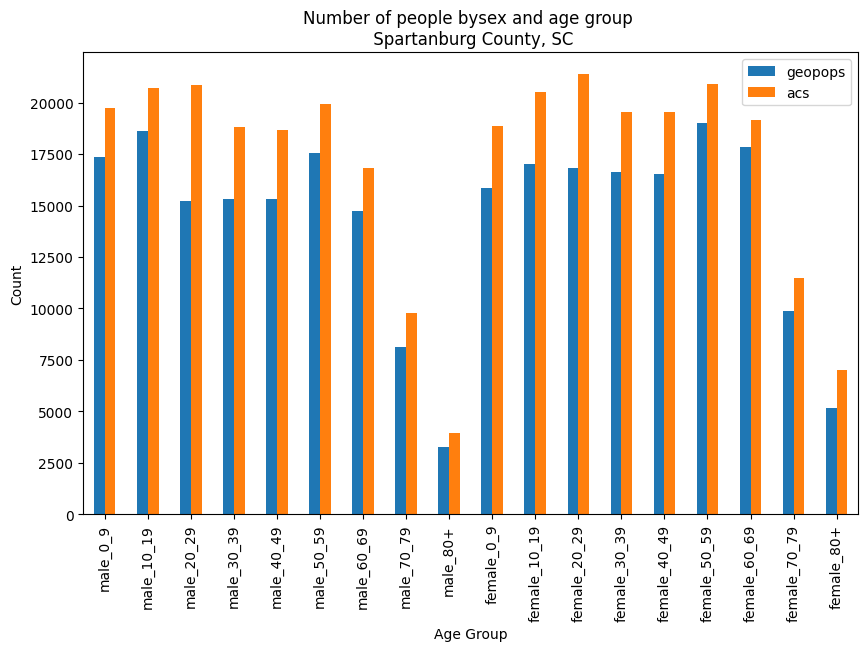

In [12]:
# Process GeoPops agents by sex and age group
sex_age = people_all.copy()

# male by age group
sex_age.loc[(sex_age['female'] == 0) & (sex_age['age'] > 0)  & (sex_age['age'] <= 9) ,'male_0_9']   = 1
sex_age.loc[(sex_age['female'] == 0) & (sex_age['age'] > 10) & (sex_age['age'] <= 19),'male_10_19'] = 1
sex_age.loc[(sex_age['female'] == 0) & (sex_age['age'] > 20) & (sex_age['age'] <= 29),'male_20_29'] = 1
sex_age.loc[(sex_age['female'] == 0) & (sex_age['age'] > 30) & (sex_age['age'] <= 39),'male_30_39'] = 1
sex_age.loc[(sex_age['female'] == 0) & (sex_age['age'] > 40) & (sex_age['age'] <= 49),'male_40_49'] = 1
sex_age.loc[(sex_age['female'] == 0) & (sex_age['age'] > 50) & (sex_age['age'] <= 59),'male_50_59'] = 1
sex_age.loc[(sex_age['female'] == 0) & (sex_age['age'] > 60) & (sex_age['age'] <= 69),'male_60_69'] = 1
sex_age.loc[(sex_age['female'] == 0) & (sex_age['age'] > 70) & (sex_age['age'] <= 79),'male_70_79'] = 1
sex_age.loc[(sex_age['female'] == 0) & (sex_age['age'] > 80),'male_80+'] = 1

# female by age group
sex_age.loc[(sex_age['female'] == 1) & (sex_age['age'] > 0)  & (sex_age['age'] <= 9) ,'female_0_9'] = 1
sex_age.loc[(sex_age['female'] == 1) & (sex_age['age'] > 10) & (sex_age['age'] <= 19) ,'female_10_19'] = 1
sex_age.loc[(sex_age['female'] == 1) & (sex_age['age'] > 20) & (sex_age['age'] <= 29),'female_20_29'] = 1
sex_age.loc[(sex_age['female'] == 1) & (sex_age['age'] > 30) & (sex_age['age'] <= 39),'female_30_39'] = 1
sex_age.loc[(sex_age['female'] == 1) & (sex_age['age'] > 40) & (sex_age['age'] <= 49),'female_40_49'] = 1
sex_age.loc[(sex_age['female'] == 1) & (sex_age['age'] > 50) & (sex_age['age'] <= 59),'female_50_59'] = 1
sex_age.loc[(sex_age['female'] == 1) & (sex_age['age'] > 60) & (sex_age['age'] <= 69),'female_60_69'] = 1
sex_age.loc[(sex_age['female'] == 1) & (sex_age['age'] > 70) & (sex_age['age'] <= 79),'female_70_79'] = 1
sex_age.loc[(sex_age['female'] == 1) & (sex_age['age'] > 80),'female_80+'] = 1

# counts by sex and age group
sex_age = sex_age[['male_0_9','male_10_19','male_20_29','male_30_39','male_40_49',
                   'male_50_59','male_60_69','male_70_79','male_80+',
                   'female_0_9','female_10_19','female_20_29','female_30_39','female_40_49',
                   'female_50_59','female_60_69','female_70_79','female_80+']]
sex_age = sex_age.fillna(0)
sex_age = sex_age.sum().reset_index().rename(columns={'index':'sex_agegroup',0:'geopops'})

# Merge GeoPops and ACS data
compare_sex_age = sex_age.merge(acs_sex_age, on='sex_agegroup', how='left').set_index('sex_agegroup')

# Make bar plot of comparison
compare_sex_age.plot(kind='bar', figsize=(10, 6))
plt.title('Number of people bysex and age group \n Spartanburg County, SC')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

GeoPops will not be exactly the same as ACS data for every variable, especially for variables that were not directly targeted in combinatorial optimization. For example, with default settings, GeoPops does not include 10-year age groups as targets. Instead, there are several target variables related to age, such as:
* B09021:18 to 34 years:Lives alone
* B11012:Two-partner household:With children of the householder under 18 years
* B09021:65 years and over:Householder living with partner or partner of householder

See `target_columns.csv` in this repo for a full list of target variables used in combinatorial optimization.

## 2.4 Assessing accuracy
We can use the Freeman-Tukey statistic (FT<sup>2</sup>) to assess the accuracy of our synthetic population for multiple target variables at once by CBG. FT<sup>2</sup> generates a mismatch score between synthetic and observed data. To do this, the next cell uses the following input files which were created in `1_run_geopops.ipynb` and stored in the pop_export and processed folders: 

| File | Description | 
| -------- | -------- |
| pop_export/hh.csv | List of households in synthetic population, which can be mapped to corresponding PUMS sample households |
| processed/census_samples.csv | PUMS sample households and variables that can be mapped to ACS target variables |
| processed/acs_targets.csv | ACS target variables that can be mapped to PUMS variables |
| pop_export/cbg_idxs.csv | File mapping cbg_id to 12-digit Census Block Group geocode |

<Axes: >

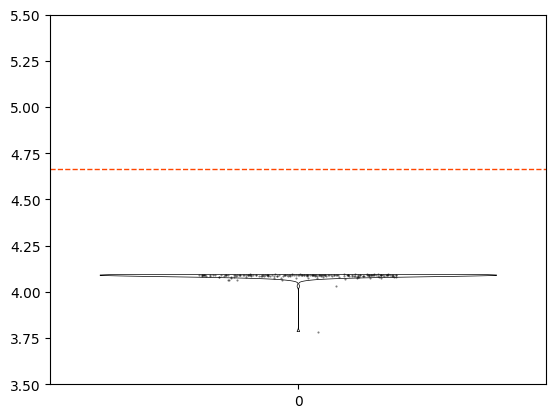

In [ ]:
# Households
hh = pd.read_csv('data/pop_export/hh.csv')
hh["sample_index"] = hh["sample_index"] - 1 ## convert sample_index to zero-indexed

# Target variables for each PUMS household
# The row number in this dataframe maps to sample_index in hh.csv (-1 because python numbering starts at 0)
samples = pd.read_csv('data/processed/census_samples.csv',dtype={"SERIALNO":str})

# Look up target vars for each hh in the synth pop
synth_samples = (hh[["cbg_id","sample_index"]]
            .merge(samples,how="left",left_on="sample_index",right_index=True)
            .drop(columns=["sample_index","SERIALNO"]))
synth_samples.head()

# Totals by cbg
synth_sums = synth_samples.groupby("cbg_id").agg("sum")

# target variables from ACS
targets_by_geo = pd.read_csv('data/processed/acs_targets.csv',dtype={"Geo":str})

# this file maps cbg_id to Geo
cbg_idxs = pd.read_csv('data/pop_export/cbg_idxs.csv',dtype={"cbg_geocode":str})

# target variables by cbg_id
targets = (targets_by_geo.merge(cbg_idxs,how="left",left_on="Geo",right_on="cbg_geocode")
        .drop(columns=["cbg_geocode","Geo"])
        .set_index("cbg_id").sort_index()
        )

# FT2 but with +1 to all values to penalize 0's less
logFT_by_cbg = np.log(4*np.sum((np.sqrt(synth_sums.values+1.0) - np.sqrt(targets.values+1.0))**2, axis=1))

# Critical value for 95% confidence interval
degrees_of_freedom = targets.shape[1] - 1
s95 = stats.chi2.ppf(0.95, degrees_of_freedom)
crit_val = np.log(s95)

# Plot the distribution of logFT_by_cbg
_, ax = plt.subplots()
ax.set_ylim(3.5, 5.5)

sns.violinplot(pd.DataFrame(logFT_by_cbg), fill=False, inner=None, color="black",
               cut=0, linewidth=0.5, gridsize=500, ax=ax)

ax.axhline(crit_val, color="orangered", linestyle="--", linewidth=1,
           label="95th percentile")

sns.stripplot(pd.DataFrame(logFT_by_cbg), color="black", size=1.5,
              jitter=0.2, alpha=0.5, ax=ax)

In this violin plot, each dot is represents a CBG in Spartanburg (N=195 in 2019). The orange line represents the 95% confidence interval based on 84 degrees of freedom (because there are 85 target variables used in the CO search). A dot below the line, indicates the synthetic data is a good match to the actual Census data for this CBG when considering all 85 target variables. This shows that our synthetic population of Spartanburg is a reasonable approximation of real data given the variables we used as targets in the CO search.